In [8]:
from pyexpat import features
from symbol import yield_arg

from numpy.ma.core import indices
%matplotlib inline
# 将生成的图表直接嵌入在网页中显示
import torch
import random
from d2l import torch as d2l # d2l包封装了一些书中常用的辅助函数（比如绘图、数据加载等），让代码更简洁

In [9]:
def synthetic_data(w, b, num_examples): # 构造人造数据集
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

features: tensor([-1.2689, -1.9665]) 
label: tensor([8.3437])


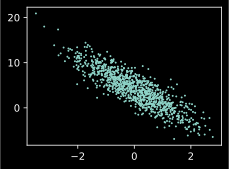

In [10]:
print('features:', features[0], '\nlabel:', labels[0])
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(),
                labels.detach().numpy(), 1);
# 人造数据集可视化

In [11]:
def data_iter(batch_size, features, labels): # 数据迭代器，将数据分成若干个批次（batch）
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i : min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)

tensor([[ 0.9100,  2.4727],
        [-0.8648,  0.5041],
        [-0.0201,  0.2840],
        [-0.7831,  0.5219],
        [ 1.1931,  0.2083],
        [-0.1642,  1.2778],
        [-0.2838,  1.8671],
        [-0.3802,  1.9318],
        [ 1.6128,  0.7227],
        [ 1.6889, -0.3664]]) 
 tensor([[-2.3999],
        [ 0.7589],
        [ 3.2115],
        [ 0.8418],
        [ 5.8992],
        [-0.4696],
        [-2.7217],
        [-3.1513],
        [ 4.9538],
        [ 8.8274]])
tensor([[ 0.3623,  0.2984],
        [ 0.6801,  0.5556],
        [-0.5876,  2.2954],
        [-1.2189,  0.0463],
        [-1.1291,  0.5923],
        [ 0.1416,  0.6526],
        [ 0.9468, -0.8425],
        [ 0.2748,  0.4454],
        [-0.0250,  0.0651],
        [ 1.3937, -0.4122]]) 
 tensor([[ 3.8996],
        [ 3.6570],
        [-4.7870],
        [ 1.6147],
        [-0.0857],
        [ 2.2746],
        [ 8.9583],
        [ 3.2299],
        [ 3.9441],
        [ 8.3883]])
tensor([[ 1.4331,  1.7094],
        [ 0.6438, -0.712

In [12]:
# 初始化模型参数
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [13]:
def linreg(X, w, b): # 线性回归模型，用于前向传播
    return torch.matmul(X, w) + b

In [14]:
def squared_loss(y_hat, y): # 均方损失
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

In [15]:
def sgd(params, lr, batch_size): # SGD梯度下降法
    with torch.no_grad(): # 提示pytorch更新参数本身不需要被记录
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [16]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')


epoch 1, loss 0.033597
epoch 2, loss 0.000120
epoch 3, loss 0.000051
